# Praktikum Machine Learning — Bab 2
## Workflow Machine Learning, CRISP-DM, dan Diagnosis Bias-Variance

| | |
|---|---|
| **Nama** | Ahmad Dandi Subhani |
| **NPM** | 202343500126 |
| **Kelas** | R7B |
| **Mata Kuliah** | Machine Learning |
| **Dosen** | Nurfidah Dwitiyanti, M.Si. |

*Notebook ini dikerjakan di Google Colab / Jupyter Notebook.*


## Ringkasan Konsep

**CRISP-DM** (*Cross-Industry Standard Process for Data Mining*) adalah kerangka kerja baku untuk proyek data mining/ML dengan **6 fase** yang berurutan namun bisa diulang (*iteratif*):

1. **Business Understanding** — memahami tujuan bisnis: masalah apa yang mau diselesaikan dan kriteria suksesnya.
2. **Data Understanding** — mengumpulkan dan mengeksplorasi data awal (distribusi, missing value, kualitas data).
3. **Data Preparation** — membersihkan dan menyiapkan data: imputasi, encoding, scaling, *sampling*.
4. **Modeling** — memilih dan melatih model, termasuk tuning hyperparameter.
5. **Evaluation** — mengevaluasi model terhadap tujuan bisnis (bukan sekadar akurasi).
6. **Deployment** — menerapkan model ke lingkungan nyata dan memonitor kinerjanya.

**Train / Validation / Test split:** data dibagi tiga peran — *train* untuk melatih, *validation* untuk memilih/tuning model, *test* untuk penilaian akhir yang belum pernah "dilihat" model. Kalau test ikut dipakai memilih model, hasilnya jadi **optimistis palsu** (data leakage).

**Stratified sampling:** teknik pembagian data yang **menjaga proporsi tiap kelas** di setiap belahan. Penting untuk dataset tidak seimbang supaya evaluasi tidak bias oleh komposisi kelas yang kebetulan.

**Bias–Variance tradeoff:** dua sumber kesalahan model. *Bias* tinggi = model terlalu sederhana, gagal menangkap pola (*underfitting*). *Variance* tinggi = model terlalu kompleks, menghafal noise data latih (*overfitting*). Model ideal menyeimbangkan keduanya.

**Learning curve** adalah alat diagnosisnya: plot skor *train* vs *validasi* terhadap jumlah data latih.
- Keduanya **rendah dan berdekatan** → *underfitting* (bias tinggi): butuh model lebih kompleks / fitur lebih baik.
- **Gap besar** antara train dan validasi → *overfitting* (variance tinggi): sederhanakan model atau tambah data.
- **Keduanya tinggi dan gap kecil** → seimbang: model siap dievaluasi di test set.


## 2.12 Implementasi Python

Pada bab ini kita mempraktikkan workflow ML pada **dataset nyata** `breast_cancer` (diagnosis tumor payudara dari 30 fitur pengukuran sel): pembagian data ber-*stratify*, pelatihan Decision Tree, dan diagnosis model lewat learning curve.

### Praktikum 2.1 — Persiapan Library

Pertama, kita memuat semua library yang dibutuhkan. Kalau cell di bawah berjalan tanpa error dan mencetak *"Library berhasil dimuat."*, berarti environment siap.

In [1]:
# Menjalankan di Google Colab / Jupyter Notebook
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.tree import DecisionTreeClassifier

print("Library berhasil dimuat.")

Library berhasil dimuat.


**Penjelasan output:**
- Tidak ada `ModuleNotFoundError`, artinya `pandas`, `numpy`, `matplotlib`, dan `scikit-learn` semuanya tersedia di environment ini.
- Baris terakhir hanyalah penanda manual bahwa cell berhasil dieksekusi sampai akhir — langkah awal sebelum menyentuh data.

### Praktikum 2.2 — Import Dataset

Dataset `breast_cancer` dimuat langsung dari scikit-learn dalam bentuk DataFrame (`as_frame=True`) supaya mudah dieksplorasi. Label 0 = *malignant* (tumor ganas), 1 = *benign* (tumor jinak).

In [2]:
data = load_breast_cancer(as_frame=True)
df = data.frame
X = df[data.feature_names]   # 30 fitur pengukuran sel
y = df['target']             # label: 0 = malignant, 1 = benign

print("Ukuran dataset:", df.shape)
print("Jumlah fitur:", len(data.feature_names))

print("\nDistribusi kelas (0 = malignant/ganas, 1 = benign/jinak):")
print(np.bincount(y))
prop = np.bincount(y) / len(y)
print(f"\nProporsi kelas 0: {prop[0]:.2%}")
print(f"Proporsi kelas 1: {prop[1]:.2%}")

print("\nLima baris pertama:")
df.head()

Ukuran dataset: (569, 31)
Jumlah fitur: 30

Distribusi kelas (0 = malignant/ganas, 1 = benign/jinak):
[212 357]

Proporsi kelas 0: 37.26%
Proporsi kelas 1: 62.74%

Lima baris pertama:


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


**Penjelasan output:**
- Dataset berukuran **(569, 32)** — 569 pasien, 30 fitur pengukuran + kolom `target` (kolom nama fitur seperti `mean radius`, `mean texture`, dst. terlihat di head).
- Distribusi kelas: **212 malignant (37,26%)** vs **357 benign (62,74%)** — dataset **tidak seimbang sempurna**, mayoritas kelas jinak. Inilah alasan pembagian ber-*stratify* pada langkah berikutnya penting: proporsi ~37:63 ini harus dijaga di data latih dan uji.
- Nilai fiturnya berupa angka kontinu hasil pengukuran laboratorium (mis. `mean radius` ≈ 17,99 pada baris pertama).

### Praktikum 2.3 — Stratified Split

Data dibagi menjadi **data latih (80%)** dan **data uji (20%)** dengan `stratify=y` agar proporsi tiap kelas tetap ~37:63 di kedua belahan, persis seperti data aslinya.

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print("Ukuran data latih:", X_train.shape, "| data uji:", X_test.shape)
print("\nProporsi kelas data latih :", np.round(np.bincount(y_train) / len(y_train), 4))
print("Proporsi kelas data uji   :", np.round(np.bincount(y_test) / len(y_test), 4))
print("Proporsi kelas data asli  :", np.round(np.bincount(y) / len(y), 4))

Ukuran data latih: (455, 30) | data uji: (114, 30)

Proporsi kelas data latih : [0.3736 0.6264]


Proporsi kelas data uji   : [0.3684 0.6316]
Proporsi kelas data asli  : [0.3726 0.6274]


**Penjelasan output:**
- Dari 569 data, **455 dipakai untuk latih** dan **114 untuk uji**.
- Proporsi kelas data latih **[0.3736, 0.6264]** dan data uji **[0.3684, 0.6316]** — **hampir identik** dengan data asli [0.3726, 0.6274], selisihnya di bawah 0,5 poin persen. Inilah bukti `stratify=y` bekerja: komposisi kelas terjaga.
- `random_state=42` membuat pembagiannya *reproducible* — setiap eksekusi ulang menghasilkan belahan yang sama persis, sehingga hasil praktikum ini bisa direplikasi.

### Praktikum 2.4 — Training & Learning Curve

Model **Decision Tree** (`max_depth=4`) dilatih, lalu `learning_curve` menghitung skor akurasi *train* dan *validasi* (CV 5 lipat) pada 8 ukuran data latih yang makin besar — dari 36 sampai 364 data.

In [4]:
model = DecisionTreeClassifier(max_depth=4, random_state=42)

train_sizes, train_scores, val_scores = learning_curve(
    model, X_train, y_train, cv=5,
    train_sizes=np.linspace(0.1, 1.0, 8),
    scoring="accuracy", shuffle=True, random_state=42)

train_mean = train_scores.mean(axis=1)
val_mean = val_scores.mean(axis=1)

print(f"{'Ukuran latih':>12} | {'Train':>7} | {'Validasi':>8}")
print("-" * 34)
for n, tr, va in zip(train_sizes, train_mean, val_mean):
    print(f"{n:>12} | {tr:>7.4f} | {va:>8.4f}")

Ukuran latih |   Train | Validasi
----------------------------------
          36 |  1.0000 |   0.8857
          83 |  0.9976 |   0.9165
         130 |  0.9985 |   0.9231
         176 |  0.9943 |   0.9165
         223 |  0.9946 |   0.9187
         270 |  0.9948 |   0.9187
         317 |  0.9924 |   0.9165
         364 |  0.9912 |   0.9385


**Penjelasan output:**
- Tabel menampilkan **8 titik** ukuran data latih: 36 → 83 → 130 → 176 → 223 → 270 → 317 → 364 (notebook ini memakai 455 data latih, 80% dipakai tiap lipatan CV lalu dipotong bertahap sesuai `train_sizes`).
- **Skor train menurun** dari 1,0000 (36 data) ke 0,9912 (364 data): makin banyak data, makin sulit dihafal sempurna — tanda model belajar pola, bukan menghafal.
- **Skor validasi naik** dari 0,8857 (36 data) ke 0,9385 (364 data): data latih yang lebih banyak membuat model **generalisasi lebih baik**. Tren "train turun, validasi naik, gap menyempit" adalah pola klasik kurva belajar yang sehat.

### Praktikum 2.5 — Evaluasi

Kita baca skor pada **ukuran data terbesar** (364 data) lalu hitung **gap** train − validasi sebagai indikator overfitting.

In [5]:
skor_train = train_mean[-1]
skor_val = val_mean[-1]
gap = skor_train - skor_val

print(f"Skor train (akurasi)    : {skor_train:.4f}")
print(f"Skor validasi (akurasi) : {skor_val:.4f}")
print(f"Gap train - validasi    : {gap:.4f} ({gap:.2%})")

if gap > 0.10:
    print("-> Gap BESAR: indikasi overfitting.")
elif gap > 0.05:
    print("-> Gap sedang: masih wajar, model cukup seimbang.")
else:
    print("-> Gap KECIL: tidak ada overfitting berarti.")

Skor train (akurasi)    : 0.9912
Skor validasi (akurasi) : 0.9385
Gap train - validasi    : 0.0527 (5.27%)
-> Gap sedang: masih wajar, model cukup seimbang.


**Penjelasan output:**
- Pada 364 data latih: skor **train = 0,9912**, skor **validasi = 0,9385**, gap = **0,0527** (5,27 poin persen).
- Keduanya **tinggi** (>90%) dan gap hanya ~5 poin — sesuai kriteria modul: **bias-variance seimbang**, tidak ada tanda overfitting serius. Model ini sudah layak dievaluasi ke data uji (test set).
- Kalau gap-nya di atas 10 poin, barulah kita patut curiga model menghafal; penanganannya: sederhanakan model (kecilkan `max_depth`) atau tambah data latih.

### Praktikum 2.6 — Visualisasi Learning Curve

Hasil tabel Praktikum 2.4 digambar sebagai kurva agar pola bias-variance-nya bisa *dilihat*.

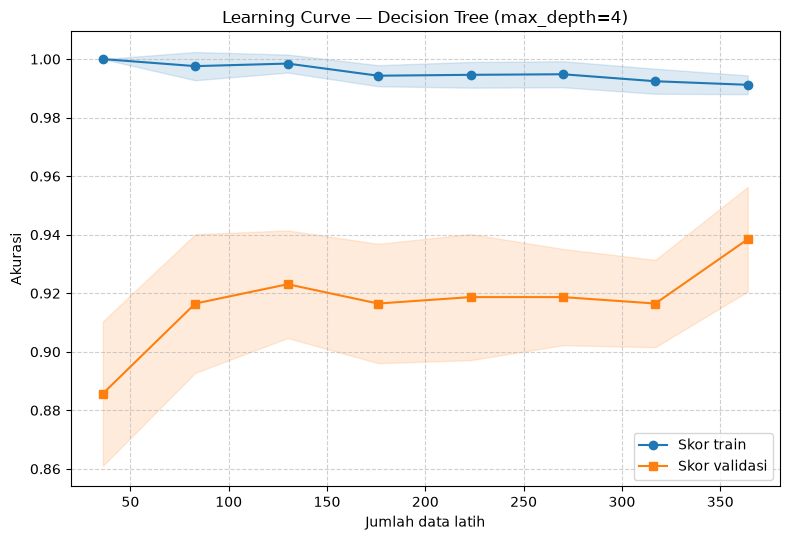

In [6]:
plt.figure(figsize=(8, 5.5))
plt.plot(train_sizes, train_mean, 'o-', label="Skor train", color="tab:blue")
plt.plot(train_sizes, val_mean, 's-', label="Skor validasi", color="tab:orange")
plt.fill_between(train_sizes,
                 train_mean - train_scores.std(axis=1),
                 train_mean + train_scores.std(axis=1),
                 alpha=0.15, color="tab:blue")
plt.fill_between(train_sizes,
                 val_mean - val_scores.std(axis=1),
                 val_mean + val_scores.std(axis=1),
                 alpha=0.15, color="tab:orange")
plt.xlabel("Jumlah data latih")
plt.ylabel("Akurasi")
plt.title("Learning Curve — Decision Tree (max_depth=4)")
plt.legend(loc="best")
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

**Penjelasan output:**
- **Kurva biru (train)** mulai di 1,00 lalu **menurun perlahan** ke ~0,99 — model dengan 364 data tidak bisa lagi menghafal semuanya, tanda ia dipaksa belajar pola umum.
- **Kurva oranye (validasi)** mulai di ~0,886 lalu **naik** ke ~0,94 — kemampuan generalisasi membaik seiring data bertambah.
- Kedua kurva **menyempit (konvergen)** di ujung kanan dengan gap ~5 poin dan keduanya di atas 0,93: pola khas model **seimbang** — bukan underfitting (validasi tidak tertinggal jauh/rendah) dan bukan overfitting (gap tidak melebar).

### 2.12.1 Interpretasi

Hasil praktikum ini cocok dengan panduan modul: **gap kecil + keduanya tinggi = bias-variance seimbang, siap evaluasi test set**. Decision Tree `max_depth=4` pada dataset breast cancer berada di titik yang baik — cukup dalam untuk menangkap pola (validasi ~94%), cukup dangkal untuk tidak menghafal (gap ~5%).

Kalau yang terjadi sebaliknya — gap besar (>10 poin) — resep perbaikannya adalah **sederhanakan model** (kecilkan `max_depth`, naikkan `min_samples_leaf`) atau **tambah data latih**. Dua resep inilah yang kita uji langsung pada bagian eksperimen di bawah.

## Eksperimen (Coba-Coba)

Bagian ini berisi percobaan mandiri: mengubah-ubah kondisi lalu mengamati apa yang terjadi pada learning curve — seperti orang yang sedang belajar mendiagnosis model.

### Eksperimen 1 — Kompleksitas pohon: `max_depth` = 1 vs 4 vs None

Parameter `max_depth` mengontrol seberapa dalam (kompleks) pohon boleh tumbuh. Kita bandingkan tiga tingkat: pohon **sangat dangkal** (depth=1), **sedang** (depth=4, dari praktikum), dan **tanpa batas** (None).

max_depth |  Train | Validasi |    Gap
--------------------------------------
        1 | 0.9258 |   0.8967 | 0.0291
        4 | 0.9912 |   0.9385 | 0.0527
     None | 1.0000 |   0.9099 | 0.0901


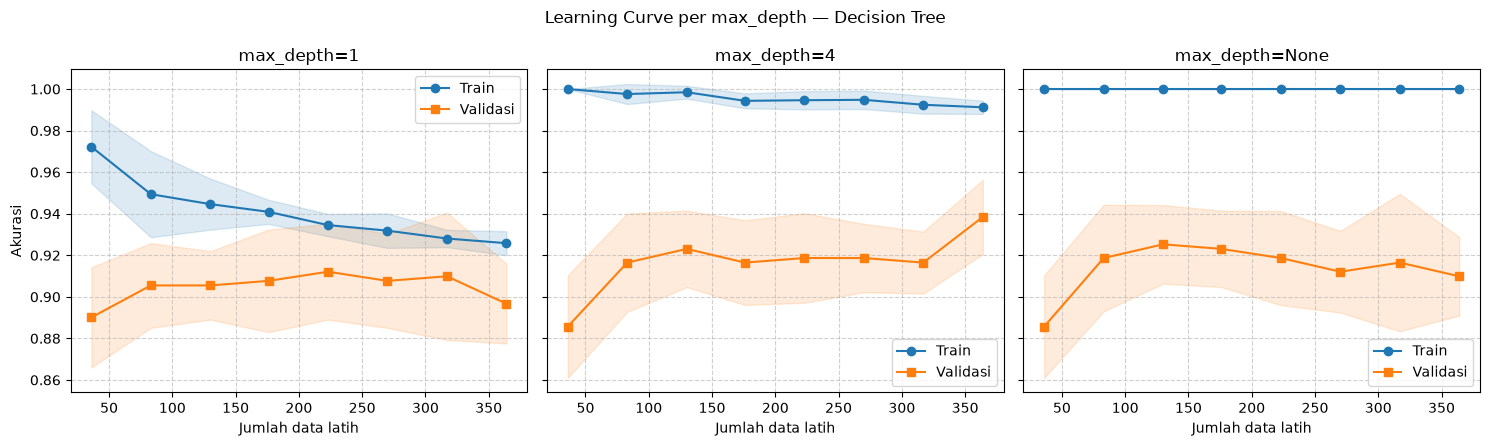

In [7]:
depths = [1, 4, None]
hasil = {}
for md in depths:
    m = DecisionTreeClassifier(max_depth=md, random_state=42)
    ts, tr, va = learning_curve(m, X_train, y_train, cv=5,
        train_sizes=np.linspace(0.1, 1.0, 8),
        scoring="accuracy", shuffle=True, random_state=42)
    hasil[str(md)] = (ts, tr.mean(axis=1), va.mean(axis=1),
                      tr.std(axis=1), va.std(axis=1))

print(f"{'max_depth':>9} | {'Train':>6} | {'Validasi':>8} | {'Gap':>6}")
print("-" * 38)
for md in depths:
    ts, trm, vam, _, _ = hasil[str(md)]
    print(f"{str(md):>9} | {trm[-1]:>6.4f} | {vam[-1]:>8.4f} | {trm[-1] - vam[-1]:>6.4f}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=True)
for ax, md in zip(axes, depths):
    ts, trm, vam, trs, vas = hasil[str(md)]
    ax.plot(ts, trm, 'o-', label="Train", color="tab:blue")
    ax.plot(ts, vam, 's-', label="Validasi", color="tab:orange")
    ax.fill_between(ts, trm - trs, trm + trs, alpha=0.15, color="tab:blue")
    ax.fill_between(ts, vam - vas, vam + vas, alpha=0.15, color="tab:orange")
    ax.set_title(f"max_depth={md}")
    ax.set_xlabel("Jumlah data latih")
    ax.grid(True, linestyle="--", alpha=0.6)
    ax.legend()
axes[0].set_ylabel("Akurasi")
plt.suptitle("Learning Curve per max_depth — Decision Tree")
plt.tight_layout()
plt.show()

**Penjelasan output & interpretasi:**
- **`max_depth=1` (underfitting / bias tinggi):** train 0,9258, validasi 0,8967, gap hanya 0,0291 — kurvanya **datar dan saling menempel**. Pohon setunggal (*stump*) terlalu sederhana: ia bahkan tidak bisa "menghafal" data latih, sehingga menambah data nyaris tidak membantu (kurva validasi stagnan di ~0,90). Terapi: tambah kompleksitas (naikkan depth) atau perbaiki fitur.
- **`max_depth=4` (seimbang):** train 0,9912, validasi 0,9385, gap 0,0527. Kurva validasi naik jelas dari 0,8857 → 0,9385 seiring data bertambah — pola ideal, *sweet spot* untuk dataset ini.
- **`max_depth=None` (overfitting / variance tinggi):** train **1,0000 sempurna di semua ukuran**, validasi hanya 0,9099, gap 0,0901. Kurva train-nya garis datar di angka 1 — pohon menghafal semua data latih. Validasi bahkan **turun** dari 0,9253 (130 data) ke 0,9099 (364 data): menambah data tidak memperbaiki apa-apa karena modelnya sudah terlalu fleksibel. Terapi: batasi depth / pruning (dibahas di Bab 5).

Kesimpulannya, inilah bukti visual *bias–variance tradeoff*: terlalu sederhana → bias, terlalu bebas → variance, dan ada titik tengah yang optimal.

### Eksperimen 2 — Apa jadinya kalau split TANPA `stratify`?

Kita ulangi pembagian data tanpa `stratify=y`, bandingkan proporsinya, lalu lihat learning curve-nya. Apakah ada bedanya?

In [8]:
# Split TANPA stratify
Xtr_ns, Xte_ns, ytr_ns, yte_ns = train_test_split(
    X, y, test_size=0.2, random_state=42)  # tanpa stratify

print("Proporsi kelas data asli      :", np.round(np.bincount(y) / len(y), 4))
print("DENGAN stratify (data latih)  :", np.round(np.bincount(y_train) / len(y_train), 4))
print("TANPA stratify (data latih)   :", np.round(np.bincount(ytr_ns) / len(ytr_ns), 4))
print("TANPA stratify (data uji)     :", np.round(np.bincount(yte_ns) / len(yte_ns), 4))

# Simulasi skenario data KECIL: 60 baris acak TANPA stratify
np.random.seed(3)
idx = np.random.choice(len(y_train), 60, replace=False)
acak = np.bincount(y_train.iloc[idx]) / 60
asli = np.bincount(y) / len(y)
print("\nSub-sampel 60 data acak TANPA stratify ->", np.round(acak, 4))
print(f"   (kelas 0 meleset {abs(acak[0] - asli[0]):.2%} dari proporsi asli "
      f"{asli[0]:.2%} -> {acak[0]:.2%})")

# Learning curve pada split tanpa stratify
m2 = DecisionTreeClassifier(max_depth=4, random_state=42)
ts2, tr2, va2 = learning_curve(m2, Xtr_ns, ytr_ns, cv=5,
    train_sizes=np.linspace(0.1, 1.0, 8), scoring="accuracy",
    shuffle=True, random_state=42)
trm2, vam2 = tr2.mean(axis=1), va2.mean(axis=1)
print(f"\nSkor akhir TANPA stratify : train={trm2[-1]:.4f}, val={vam2[-1]:.4f}, gap={trm2[-1] - vam2[-1]:.4f}")
print(f"Skor akhir DENGAN stratify : train={train_mean[-1]:.4f}, val={val_mean[-1]:.4f}, gap={train_mean[-1] - val_mean[-1]:.4f}")

Proporsi kelas data asli      : [0.3726 0.6274]
DENGAN stratify (data latih)  : [0.3736 0.6264]
TANPA stratify (data latih)   : [0.3714 0.6286]
TANPA stratify (data uji)     : [0.3772 0.6228]

Sub-sampel 60 data acak TANPA stratify -> [0.5 0.5]
   (kelas 0 meleset 12.74% dari proporsi asli 37.26% -> 50.00%)



Skor akhir TANPA stratify : train=0.9885, val=0.9231, gap=0.0654
Skor akhir DENGAN stratify : train=0.9912, val=0.9385, gap=0.0527


**Penjelasan output & interpretasi:**
- Pada dataset sebesar ini (569 data), split tanpa stratify kebetulan **masih mirip**: proporsi latih [0,3714 / 0,6286] vs asli [0,3726 / 0,6274] — selisihnya tidak sampai 0,2 poin. Learning curve-nya pun mirip (validasi akhir 0,9231 vs 0,9385 dengan stratify; gap 0,0654 vs 0,0527).
- **Tapi itu keberuntungan, bukan jaminan.** Simulasi 60 data acak tanpa stratify menghasilkan proporsi **50/50** — meleset **12,74 poin** dari aslinya (37,26% → 50%). Pada dataset kecil atau kelas sangat minoritas, satu kali `train_test_split` tanpa stratify bisa membuat lipatan evaluasi nyaris tanpa sampel kelas minoritas, sehingga skor validasi jadi **acak dan tidak bisa dipercaya**.
- Kesimpulan: `stratify` adalah **asuransi murah**. Pada data besar efeknya kecil, pada data kecil ia menyelamatkan evaluasi. Karena biayanya nol (satu argumen), selalu pakai untuk klasifikasi.

### Eksperimen 3 — Decision Tree vs Logistic Regression: siapa yang lebih "lapar data"?

Dua model berbeda dibandingkan lewat learning curve: Decision Tree (depth=4) vs **Logistic Regression** (dengan StandardScaler, karena fitur punya skala berbeda — scaling membuat optimasinya konvergen).

Decision Tree (depth=4): train=0.9912, val=0.9385, gap=0.0527


Logistic Regression: train=0.9896, val=0.9802, gap=0.0093

Skor validasi pada HANYA 36 data latih:
  Decision Tree      : 0.8857
  Logistic Regression: 0.9538


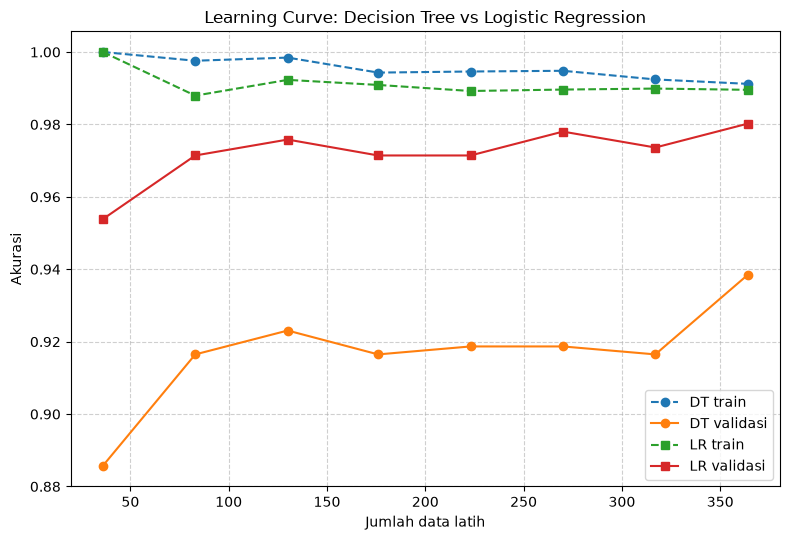

In [9]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline

dt = DecisionTreeClassifier(max_depth=4, random_state=42)
lr = make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000, random_state=42))

kurva = {}
for nama, m in [("Decision Tree (depth=4)", dt), ("Logistic Regression", lr)]:
    ts3, tr3, va3 = learning_curve(m, X_train, y_train, cv=5,
        train_sizes=np.linspace(0.1, 1.0, 8), scoring="accuracy",
        shuffle=True, random_state=42)
    trm3, vam3 = tr3.mean(axis=1), va3.mean(axis=1)
    kurva[nama] = (ts3, trm3, vam3)
    print(f"{nama}: train={trm3[-1]:.4f}, val={vam3[-1]:.4f}, gap={trm3[-1] - vam3[-1]:.4f}")

print("\nSkor validasi pada HANYA 36 data latih:")
print(f"  Decision Tree      : {kurva['Decision Tree (depth=4)'][2][0]:.4f}")
print(f"  Logistic Regression: {kurva['Logistic Regression'][2][0]:.4f}")

plt.figure(figsize=(8, 5.5))
t_dt, tr_dt, va_dt = kurva["Decision Tree (depth=4)"]
t_lr, tr_lr, va_lr = kurva["Logistic Regression"]
plt.plot(t_dt, tr_dt, 'o--', label="DT train")
plt.plot(t_dt, va_dt, 'o-', label="DT validasi")
plt.plot(t_lr, tr_lr, 's--', label="LR train")
plt.plot(t_lr, va_lr, 's-', label="LR validasi")
plt.xlabel("Jumlah data latih")
plt.ylabel("Akurasi")
plt.title("Learning Curve: Decision Tree vs Logistic Regression")
plt.legend(loc="best")
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

**Penjelasan output & interpretasi:**
- **Logistic Regression: validasi akhir 0,9802, gap hanya 0,0093** — kurva train dan validasinya hampir menyatu. Model linear ini punya bias sedikit lebih tinggi di awal tapi variansnya sangat rendah: ia tidak menghafal, sehingga skornya stabil.
- **Decision Tree (depth=4): validasi akhir 0,9385, gap 0,0527** — lebih "rakus": dengan hanya 36 data latih, validasinya cuma **0,8857**, sedangkan LR sudah **0,9538**. Pohon butuh lebih banyak data untuk mencapai performa yang sama — ia lebih *data-hungry*.
- Kenapa begitu? Decision Tree membelah ruang fitur secara rekursif (fleksibel, varians lebih tinggi), sedangkan regresi logistik hanya mencari satu batas linear (kaku tapi stabil). Pada dataset ini yang polanya cukup linear, **model sederhana justru menang**: LR lebih akurat DAN lebih stabil.
- Pelajaran praktis: jangan berasumsi model kompleks selalu lebih baik — learning curve membuktikannya secara visual. (Catatan: LR di sini dipakai dengan `StandardScaler` karena tanpa scaling optimasinya gagal konvergen — preprocessing yang benar adalah bagian dari workflow, Bab 4.)

## Studi Kasus — Mendiagnosis Model Nyata dari Learning Curve

> Modul Bab 2 tidak memuat tabel studi kasus eksplisit. Sebagai gantinya, kita memakai **hasil learning curve di atas** sebagai "pasien": didiagnosis seperti dokter membaca hasil lab, lalu diberi resep tindakan.

**Diagnosis model Decision Tree (max_depth=4) pada breast cancer:**
1. **Gejala yang terbaca:** skor train 0,9912 dan validasi 0,9385 (gap 5,27 poin). Kurva validasi naik dari 0,8857 → 0,9385 seiring data bertambah; kurva train turun perlahan dari 1,0000.
2. **Diagnosis: SEHAT / seimbang.** Bukan underfitting (validasi 93,85% jelas tinggi, kurva validasi masih naik — model masih "belajar"), bukan overfitting (gap hanya 5 poin, jauh di bawah ambang bahaya ~10 poin).
3. **Resep tindakan:**
   - Lanjut ke **evaluasi test set** (114 data yang belum tersentuh) untuk angka final yang jujur.
   - Kalau nanti skor test jauh di bawah validasi, barulah curiga dan kembali ke fase *Modeling* (CRISP-DM itu iteratif).
   - Opsional: karena kurva validasi masih naik di ujung kanan, **menambah data** kemungkinan masih menaikkan performa — sesuai anjuran modul: *"gap kecil, tambah data"* untuk kasus overfitting ringan, dan di sini situasinya bahkan lebih baik.

**Bandingkan dengan dua "pasien" lain dari eksperimen:**
- *Pasien depth=1*: train 0,9258 / val 0,8967, kurva datar → **underfitting kronis**. Resep: naikkan kompleksitas model (depth lebih besar), bukan tambah data — kurvanya sudah stagnan, data baru tidak akan menolong.
- *Pasien depth=None*: train 1,0000 / val 0,9099, gap 9 poin, validasi turun saat data ditambah → **overfitting**. Resep: sederhanakan (batasi depth, pruning di Bab 5) atau tambah data latih.

Inilah gunanya learning curve dalam workflow nyata: **satu gambar menentukan terapi yang berbeda** — salah baca gejalanya, salah pula obatnya (mis. menambah data untuk model yang underfit hanya membuang waktu).

## 2.13 Latihan Praktikum

### Latihan 1 — Memetakan Proyek Nyata ke CRISP-DM

**Soal:** pilih studi kasus **prediksi churn pelanggan telekomunikasi** (dataset Telco Customer Churn). Tuliskan aktivitas konkret pada 6 fase CRISP-DM.

Pertama, kita intip dulu datasetnya supaya pemetaannya konkret (bukan karangan).

In [10]:
path_churn = "/home/hatch/workspace/user/files/WA_Fn-UseC_-Telco-Customer-Churn.csv"
try:
    churn = pd.read_csv(path_churn)
    print("Shape:", churn.shape)
    print("\nDistribusi Churn (target):")
    print(churn['Churn'].value_counts())
    print((churn['Churn'].value_counts(normalize=True) * 100).round(2))
    kosong = (churn['TotalCharges'].astype(str).str.strip() == '').sum()
    print("\nBaris dengan TotalCharges kosong:", kosong)
    print("\nRata-rata tenure (bulan) per status churn:")
    print(churn.groupby('Churn')['tenure'].mean().round(1))
    print("\nRata-rata MonthlyCharges per status churn:")
    print(churn.groupby('Churn')['MonthlyCharges'].mean().round(1))
    print("\nChurn rate per jenis kontrak:")
    print(pd.crosstab(churn['Contract'], churn['Churn'], normalize='index').round(3))
except FileNotFoundError:
    print("File churn tidak ditemukan di", path_churn)

Shape: (7043, 21)

Distribusi Churn (target):
Churn
No     5174
Yes    1869
Name: count, dtype: int64
Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64

Baris dengan TotalCharges kosong: 11

Rata-rata tenure (bulan) per status churn:
Churn
No     37.6
Yes    18.0
Name: tenure, dtype: float64

Rata-rata MonthlyCharges per status churn:
Churn
No     61.3
Yes    74.4
Name: MonthlyCharges, dtype: float64

Churn rate per jenis kontrak:
Churn              No    Yes
Contract                    
Month-to-month  0.573  0.427
One year        0.887  0.113
Two year        0.972  0.028


**Penjelasan output:**
- Dataset berisi **7.043 pelanggan** dengan **21 kolom** — targetnya kolom `Churn` (Yes/No).
- Churn hanya **1.869 pelanggan (26,54%)** — kelas minoritas, dataset **tidak seimbang** (mirip breast cancer tadi, tapi lebih timpang). Evaluasi nanti tidak boleh mengandalkan akurasi mentah.
- Ada **11 baris** dengan `TotalCharges` kosong (terbaca sebagai string kosong, bukan NaN) — data kotor nyata yang harus dibersihkan di fase Data Preparation.
- Sinyal bisnisnya jelas: pelanggan yang churn rata-rata baru **18,0 bulan** berlangganan (vs 37,6 bulan yang bertahan) dan membayar **Rp-lebih-mahal**: tagihan bulanan rata-rata 74,4 vs 61,3. Kontrak *month-to-month* churn-nya **42,7%**, sedangkan kontrak 2 tahun cuma **2,8%**.

**Jawaban — pemetaan ke 6 fase CRISP-DM:**

| Fase | Aktivitas konkret pada proyek churn |
|---|---|
| **1. Business Understanding** | Tujuan: menurunkan churn pelanggan. Kriteria sukses: model bisa mengidentifikasi 80% calon churn dengan presisi yang bisa ditindaklanjuti tim retensi; metrik utama **recall** kelas churn (lebih baik salah alarm daripada kehilangan pelanggan). |
| **2. Data Understanding** | Eksplorasi 7.043 baris × 21 kolom: churn 26,54% (imbalance); 11 baris `TotalCharges` kosong; fitur kandidat kuat: `Contract` (month-to-month churn 42,7%), `tenure` (churn: 18,0 vs 37,6 bulan), `MonthlyCharges` (74,4 vs 61,3), `InternetService` fiber optic churn 41,9%. |
| **3. Data Preparation** | Konversi `TotalCharges` ke numerik (11 baris kosong → NaN → imputasi median); encoding kolom kategorikal (one-hot); scaling fitur numerik; **stratified split** 80/20 menjaga proporsi churn 26,54%; pertimbangkan SMOTE/undersampling untuk imbalance (dibahas Bab 3). |
| **4. Modeling** | Latih baseline Logistic Regression, lalu Decision Tree & Random Forest; tuning via learning curve + validasi silang ber-*stratify*; bandingkan F1/recall kelas churn, bukan sekadar akurasi. |
| **5. Evaluation** | Uji pada test set yang belum tersentuh: cek confusion matrix, precision–recall; validasi dengan tim bisnis — apakah daftar "pelanggan berisiko" masuk akal (mis. didominasi kontrak bulanan + tenure pendek)? Kalau tidak, kembali ke fase 2/3. |
| **6. Deployment** | Model di-*deploy* sebagai skor churn mingguan di dashboard CRM; pelanggan skor tinggi otomatis masuk daftar prioritas tim retensi (penawaran kontrak tahunan/diskon); monitor *data drift* — kalau pola churn berubah, latih ulang. |

### Latihan 2 — Diagnosis Bias-Variance (Praktikum 2.7)

**Soal:** bandingkan learning curve untuk `max_depth` = [1, 4, None] pada breast cancer; cetak skor train/validasi tiap nilai; tulis diagnosis (underfitting / overfitting / seimbang) untuk tiap nilai.

In [11]:
print("=== Praktikum 2.7: diagnosis bias-variance per max_depth ===")
print(f"{'max_depth':>9} | {'Train':>6} | {'Validasi':>8} | {'Gap':>6} | Diagnosis")
print("-" * 62)
for md in [1, 4, None]:
    m = DecisionTreeClassifier(max_depth=md, random_state=42)
    ts, tr, va = learning_curve(m, X_train, y_train, cv=5,
        train_sizes=np.linspace(0.1, 1.0, 8), scoring="accuracy",
        shuffle=True, random_state=42)
    trf, vaf = tr.mean(axis=1)[-1], va.mean(axis=1)[-1]
    gap = trf - vaf
    if trf < 0.95 and vaf < 0.92:
        diag = "UNDERFITTING (bias tinggi)"
    elif gap > 0.08:
        diag = "OVERFITTING (variance tinggi)"
    else:
        diag = "SEIMBANG"
    print(f"{str(md):>9} | {trf:>6.4f} | {vaf:>8.4f} | {gap:>6.4f} | {diag}")

=== Praktikum 2.7: diagnosis bias-variance per max_depth ===
max_depth |  Train | Validasi |    Gap | Diagnosis
--------------------------------------------------------------


        1 | 0.9258 |   0.8967 | 0.0291 | UNDERFITTING (bias tinggi)


        4 | 0.9912 |   0.9385 | 0.0527 | SEIMBANG


     None | 1.0000 |   0.9099 | 0.0901 | OVERFITTING (variance tinggi)


**Jawaban — diagnosis tertulis tiap nilai:**
- **`max_depth=1` → UNDERFITTING (bias tinggi).** Train 0,9258 dan validasi 0,8967 — keduanya **rendah** dan gap kecil (0,0291). Pohon setunggal tidak cukup ekspresif untuk 30 fitur; ia gagal bahkan pada data latihnya sendiri. Terapi: naikkan kompleksitas, bukan tambah data.
- **`max_depth=4` → SEIMBANG.** Train 0,9912, validasi 0,9385, gap 0,0527. Kedua skor tinggi dan gap kecil — titik optimal bias-variance untuk dataset ini.
- **`max_depth=None` → OVERFITTING (variance tinggi).** Train **1,0000** (hafal total), validasi 0,9099, gap 0,0901 — model terlalu fleksibel dan mengikuti noise. Terapi: batasi depth atau pruning (Bab 5), atau tambah data latih.

Aturan praktis yang dipakai: kedua skor rendah → underfitting; gap > 8 poin → overfitting; sisanya seimbang. Ambang ini heuristik — yang penting konsisten dan selalu dibaca bersama bentuk kurvanya, bukan satu angka saja.

## Kesimpulan Bab 2

1. **CRISP-DM** memberi struktur 6 fase (business → data → preparation → modeling → evaluation → deployment) yang iteratif; kegagalan di fase evaluasi berarti kembali ke fase sebelumnya, bukan mengulang dari nol.
2. Pembagian data harus memakai **stratified sampling** (`stratify=y`) agar proporsi kelas terjaga — terbukti menjaga rasio 37:63 di data latih maupun uji pada breast cancer, dan menjadi penyelamat pada data kecil.
3. **Learning curve** adalah alat diagnosis utama: kedua skor rendah & rapat → underfitting; gap besar → overfitting; keduanya tinggi & gap kecil → seimbang (model kita: train 0,9912 / val 0,9385 / gap 5,27%).
4. **Bias–variance tradeoff** terbukti empiris: `max_depth=1` underfit (val 0,8967), `max_depth=None` overfit (gap 9 poin), `max_depth=4` seimbang — kompleksitas model harus disesuaikan dengan data.
5. Model sederhana bisa menang: **Logistic Regression** (dengan scaling) mencapai validasi 0,9802 dengan gap 0,0093 — mengalahkan Decision Tree pada dataset ini karena lebih stabil dan tidak "lapar data".